# Batch Gradient Descent

This notebook demonstrates Batch Gradient Descent from scratch using Linear Regression for House Price Prediction.


## Import Libraries

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


## Load Dataset

In [2]:

df = pd.read_csv("house price dataset.csv")
df.head()


,House_Area_sqft,Bedrooms,Bathrooms,Location_Score,Property_Age,House_Price
0,1360,1,3,3.02,49,548413.0
1,4272,1,2,3.01,2,1433959.0
2,3592,3,2,5.83,43,1348990.0
3,966,5,2,6.34,2,730141.0
4,4926,4,4,6.22,21,2026820.0


## Select Independent and Dependent Variables

In [3]:

X = df["House_Area_sqft"].values
y = df["House_Price"].values


## Split Dataset

In [4]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


## Normalize Data

In [5]:

X_train = X_train / X_train.max()
X_test = X_test / X_test.max()

y_train = y_train / y_train.max()
y_test = y_test / y_test.max()


## Initialize Parameters

In [6]:

m = 0
b = 0

learning_rate = 0.01
epochs = 1000

n = len(X_train)

losses = []


## Batch Gradient Descent Algorithm

In [7]:

for epoch in range(epochs):

    y_pred = m * X_train + b

    dm = (-2/n) * np.sum(X_train * (y_train - y_pred))
    db = (-2/n) * np.sum(y_train - y_pred)

    m = m - learning_rate * dm
    b = b - learning_rate * db

    loss = np.mean((y_train - y_pred) ** 2)
    losses.append(loss)

print("Slope:", m)
print("Intercept:", b)


Slope: 0.5636824815713076
Intercept: 0.25691422195938723


## Plot Loss Curve

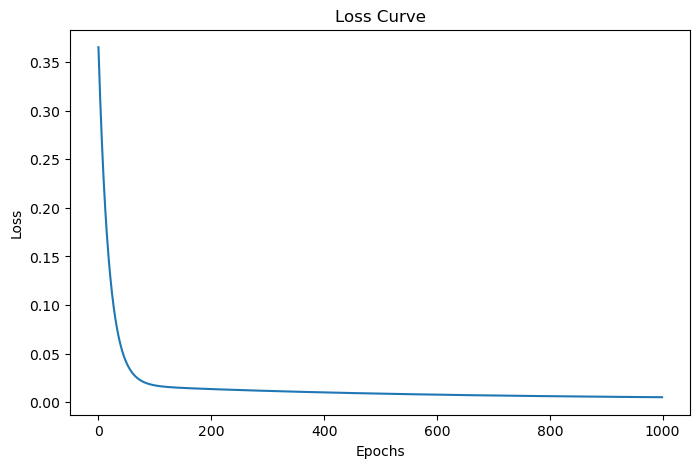

In [8]:

plt.figure(figsize=(8,5))
plt.plot(losses)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.show()



## Predictions

In [9]:

y_pred_test = m * X_test + b


## Evaluation Metrics

In [10]:

mse = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_test)

print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)


MSE: 0.009265752656089775
RMSE: 0.09625877963120962
R2 Score: 0.7792279137954515


## Actual vs Predicted Graph

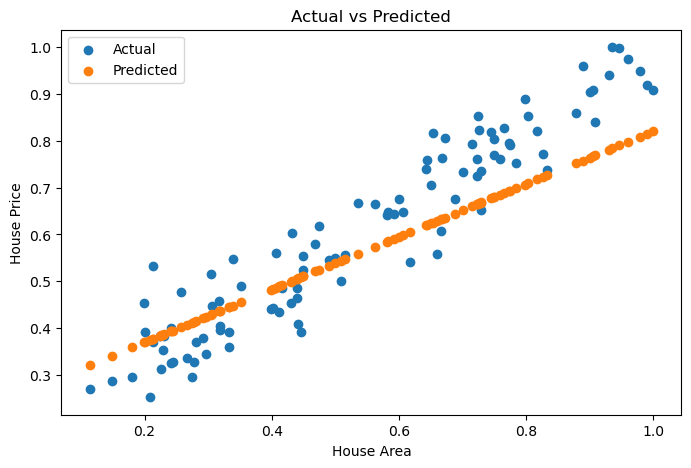

In [11]:

plt.figure(figsize=(8,5))
plt.scatter(X_test, y_test, label="Actual")
plt.scatter(X_test, y_pred_test, label="Predicted")

plt.xlabel("House Area")
plt.ylabel("House Price")
plt.title("Actual vs Predicted")

plt.legend()
plt.show()


# Final Conclusion

- Batch Gradient Descent updates parameters using the full dataset.
- Loss decreases gradually after each epoch.
- Model performance can be measured using MSE, RMSE, and R² score.
- This method gives stable convergence but may be slower on large datasets.
